In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import cv2
from PIL import Image

# Ganti dengan nama folder dataset asli kamu di Kaggle
TRAIN_DIR = '/kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/train'
TEST_DIR = '/kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/test'

IMG_SIZE = (300, 300)
BATCH_SIZE = 32
EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE

2026-06-23 04:22:42.237997: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782188562.426327      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782188562.477368      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782188562.899862      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782188562.899899      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782188562.899902      23 computation_placer.cc:177] computation placer alr

In [2]:
def load_and_clean_paths(directory):
    file_paths = []
    labels = []
    class_names = sorted(os.listdir(directory))
    
    for label_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(directory, class_name)
        if not os.path.isdir(class_dir):
            continue
        for file_name in os.listdir(class_dir):
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(class_dir, file_name)
                try:
                    # Memeriksa format internal file secara riil 🛡️
                    with Image.open(file_path) as img:
                        if img.format not in ['JPEG', 'PNG']:
                            print(f"File non-gambar diabaikan: {file_path}")
                            continue
                        img.verify() 
                    file_paths.append(file_path)
                    labels.append(label_idx)
                except Exception:
                    print(f"File rusak diabaikan: {file_path}")
    return file_paths, labels, class_names

train_paths, train_labels, class_names = load_and_clean_paths(TRAIN_DIR)
test_paths, test_labels, _ = load_and_clean_paths(TEST_DIR)

def parse_image(filename, label):
    image_string = tf.io.read_file(filename)
    image = tf.io.decode_image(image_string, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(len(train_paths)).map(parse_image).batch(BATCH_SIZE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(parse_image).batch(BATCH_SIZE)

File non-gambar diabaikan: /kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/train/fake/fake_040620.jpg
File non-gambar diabaikan: /kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/train/fake/fake_015223.jpg
File non-gambar diabaikan: /kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata/test/real/real_055571.jpg


I0000 00:00:1782189691.477280      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


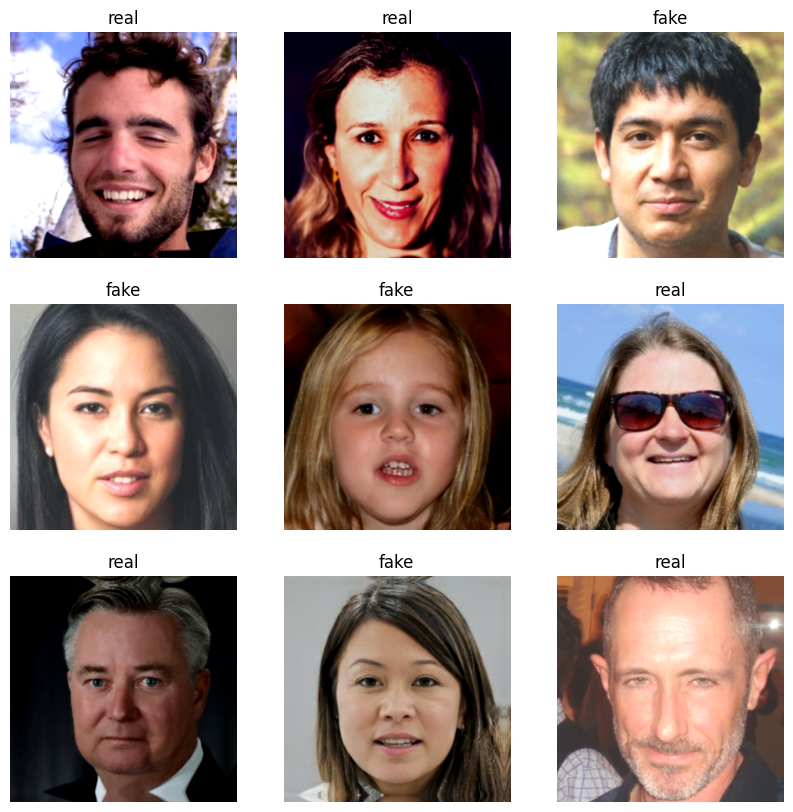

In [3]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(factor=0.2),
    layers.RandomContrast(factor=0.2)
])

def augment_fn(images, labels):
    return data_augmentation(images, training=True), labels

train_ds = train_ds.map(augment_fn, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# Menampilkan sampel gambar
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.show()

In [4]:
base_model = tf.keras.applications.EfficientNetV2B3(
    input_shape=(300, 300, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False 

inputs = tf.keras.Input(shape=(300, 300, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15


I0000 00:00:1782189714.447207      66 service.cc:152] XLA service 0x7dcae0418ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782189714.447255      66 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782189718.414522      66 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782189739.174517      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2826/2826 ━━━━━━━━━━━━━━━━━━━━ 671s 222ms/step - accuracy: 0.6956 - loss: 0.5806 - val_accuracy: 0.5945 - val_loss: 0.6986
Epoch 2/15
2826/2826 ━━━━━━━━━━━━━━━━━━━━ 577s 204ms/step - accuracy: 0.7513 - loss: 0.5131 - val_accuracy: 0.6314 - val_loss: 0.6714
Epoch 3/15
2826/2826 ━━━━━━━━━━━━━━━━━━━━ 583s 206ms/step - accuracy: 0.7668 - loss: 0.4904 - val_accuracy: 0.6475 - val_loss: 0.6524
Epoch 4/15
2826/2826 ━━━━━━━━━━━━━━━━━━━━ 574s 203ms/step - accuracy: 0.7732 - loss: 0.4777 - val_accuracy: 0.6529 - val_loss: 0.6461
Epoch 5/15
2826/2826 ━━━━━━━━━━━━━━━━━━━━ 572s 202ms/step - accuracy: 0.7815 - loss: 0.4670 - val_accuracy: 0.6647 - val_loss: 0.6366
Epoch 6/15
2826/2826 ━━━━━━━━━━━━━━━━━━━━ 579s 205ms/step - accuracy: 0.7824 - loss: 0.4647 - val_accuracy: 0.6775 - val_loss: 0.6160
Epoch 7/15
2826/2826 ━━━━━━━━━━━━━━━━━━━━ 586s 207ms/step - accuracy: 0.7861 - loss: 0.4595 - val_accuracy: 0.6828 - val_loss: 0.6097
Epoch 8/15
2826/2826 ━━━━━━━━━━━━━━━━━━━━ 595s 210ms/step - accuracy: 0.7

681/681 ━━━━━━━━━━━━━━━━━━━━ 65s 80ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        fake       0.64      0.91      0.75     10399
        real       0.87      0.53      0.66     11376

    accuracy                           0.71     21775
   macro avg       0.75      0.72      0.71     21775
weighted avg       0.76      0.71      0.70     21775



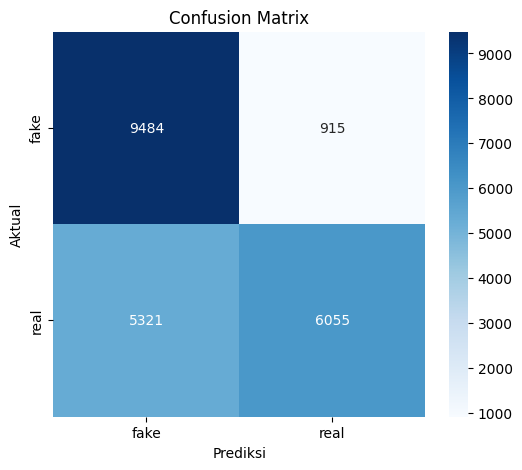

In [6]:
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

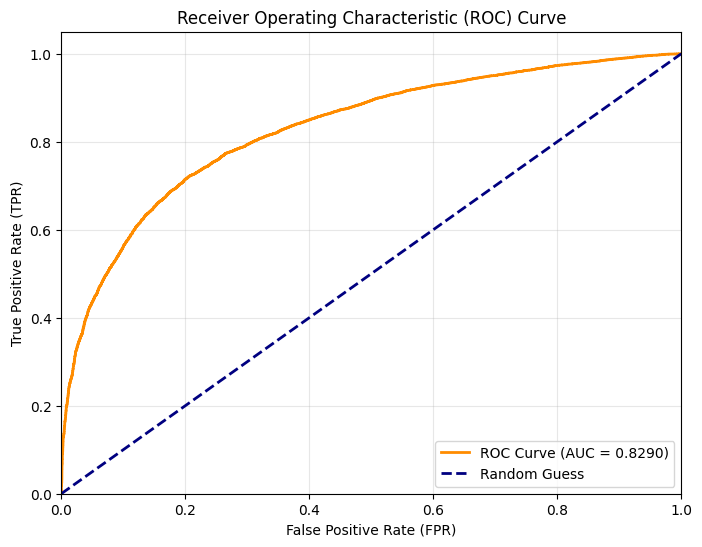

In [7]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# 1. Menghitung False Positive Rate (FPR) dan True Positive Rate (TPR)
# Menggunakan y_true dan y_pred_probs yang sudah Anda definisikan sebelumnya
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# 2. Membuat Plot Kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Mengekstrak fitur dari model untuk PCA...
681/681 ━━━━━━━━━━━━━━━━━━━━ 64s 79ms/step


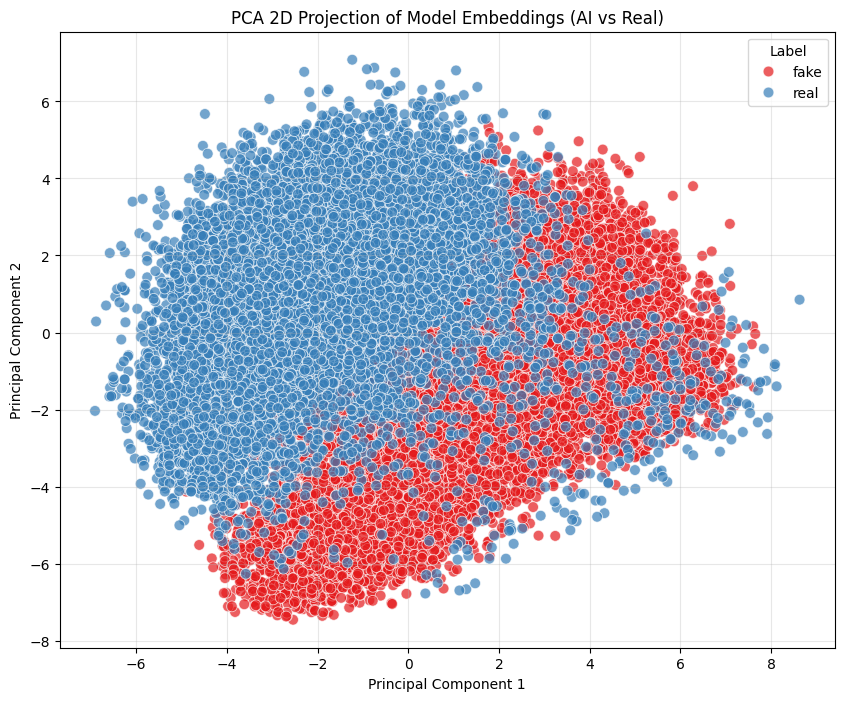

In [8]:
from sklearn.decomposition import PCA
import pandas as pd

print("Mengekstrak fitur dari model untuk PCA...")

# 1. Membuat 'Feature Extractor'
# Kita memotong model sebelum layer klasifikasi terakhir (Dense) untuk mengambil fitur mentahnya
# Berdasarkan arsitektur Anda, kita ambil output dari layer GlobalAveragePooling2D atau Dropout
feature_extractor = tf.keras.Model(inputs=model.inputs, outputs=model.layers[-2].output)

# 2. Ekstrak fitur dari seluruh data testing
features = feature_extractor.predict(test_ds)

# 3. Menggunakan PCA untuk mereduksi dimensi fitur menjadi 2D (X dan Y)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

# 4. Memasukkan hasil PCA ke dalam DataFrame agar mudah diplot
pca_df = pd.DataFrame(data=pca_result, columns=['PCA_1', 'PCA_2'])
# Mengubah angka label asli (0 dan 1) menjadi nama teks (misal: 'Fake', 'Real')
pca_df['Label'] = [class_names[label] for label in y_true]

# 5. Membuat Plot Scatter PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA_1', y='PCA_2',
    hue='Label',
    palette='Set1', # Anda bisa ganti warna, misal 'rocket' atau 'viridis'
    data=pca_df,
    legend='full',
    alpha=0.7,
    s=60 # Ukuran titik
)

plt.title('PCA 2D Projection of Model Embeddings (AI vs Real)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(alpha=0.3)
plt.show()

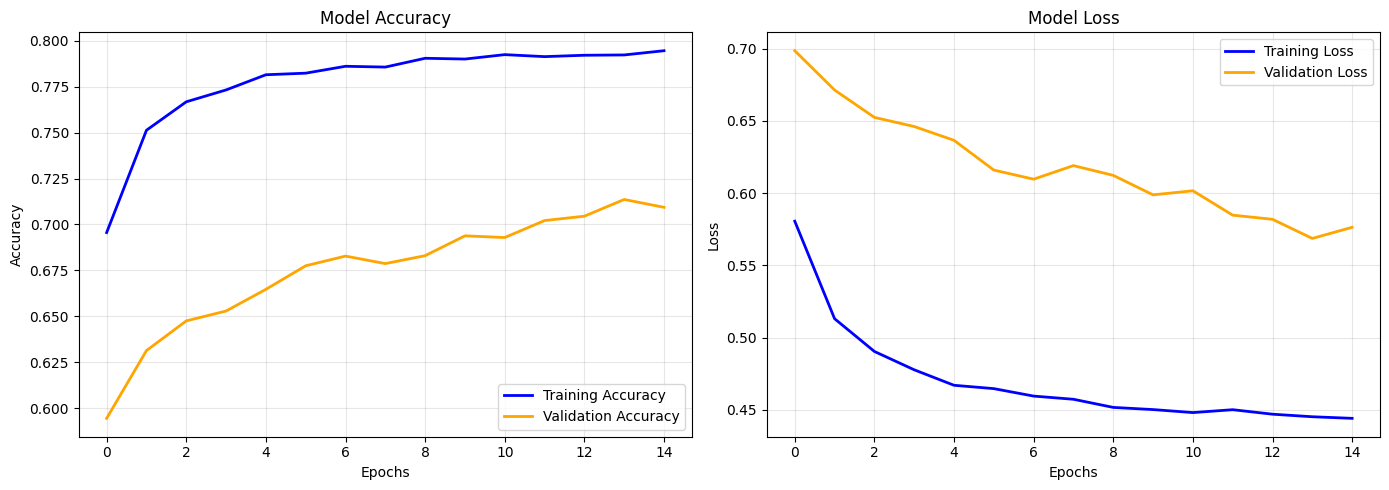

In [9]:
import matplotlib.pyplot as plt

# Membuat figure dengan 2 subplot (kiri untuk Akurasi, kanan untuk Loss)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Akurasi
ax[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue', lw=2)
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', lw=2)
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend(loc='lower right')
ax[0].grid(alpha=0.3)

# Plot Loss
ax[1].plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
ax[1].plot(history.history['val_loss'], label='Validation Loss', color='orange', lw=2)
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend(loc='upper right')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

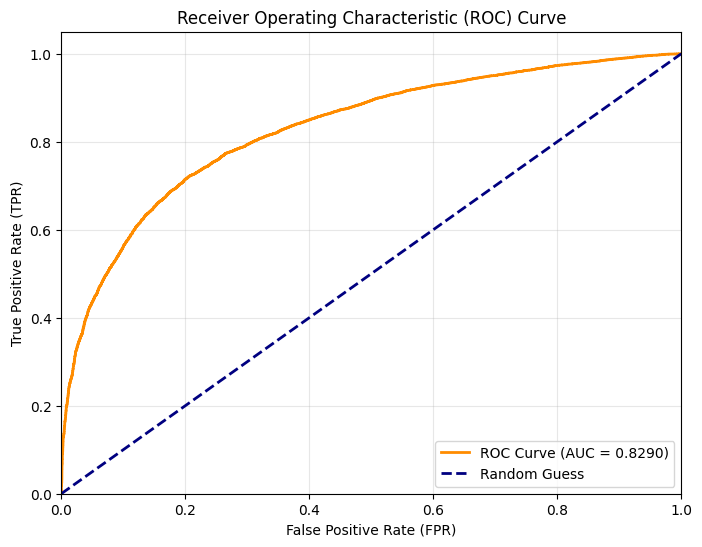

In [10]:
from sklearn.metrics import roc_curve, auc

# Menghitung False Positive Rate dan True Positive Rate
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Plot Kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Mengeksekusi t-SNE... 


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


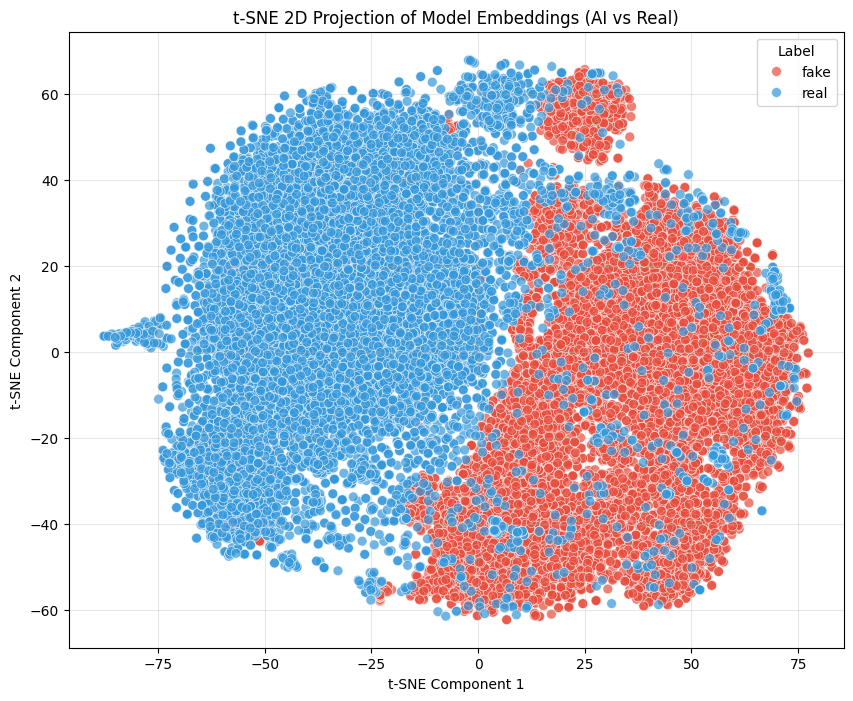

In [11]:
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns

print("Mengeksekusi t-SNE... ")

# Kita asumsikan 'features' sudah Anda buat dari kode ekstraksi sebelumnya
# Jika belum, jalankan ulang 2 baris ini:
# feature_extractor = tf.keras.Model(inputs=model.inputs, outputs=model.layers[-2].output)
# features = feature_extractor.predict(test_ds)

# 1. Menggunakan t-SNE untuk mereduksi dimensi
# perplexity biasanya diatur antara 30-50. Jika hasil kurang bagus, Anda bisa ubah angkanya.
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)
tsne_result = tsne.fit_transform(features)

# 2. Memasukkan hasil ke DataFrame
tsne_df = pd.DataFrame(data=tsne_result, columns=['t-SNE_1', 't-SNE_2'])
tsne_df['Label'] = [class_names[label] for label in y_true]

# 3. Plot t-SNE menggunakan warna dari Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='t-SNE_1', y='t-SNE_2',
    hue='Label',
    palette=['#e74c3c', '#3498db'], # Warna merah (fake) dan biru (real) agar kontras
    data=tsne_df,
    legend='full',
    alpha=0.7,
    s=50,
    edgecolor='w',
    linewidth=0.5
)

plt.title('t-SNE 2D Projection of Model Embeddings (AI vs Real)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(alpha=0.3)
plt.show()

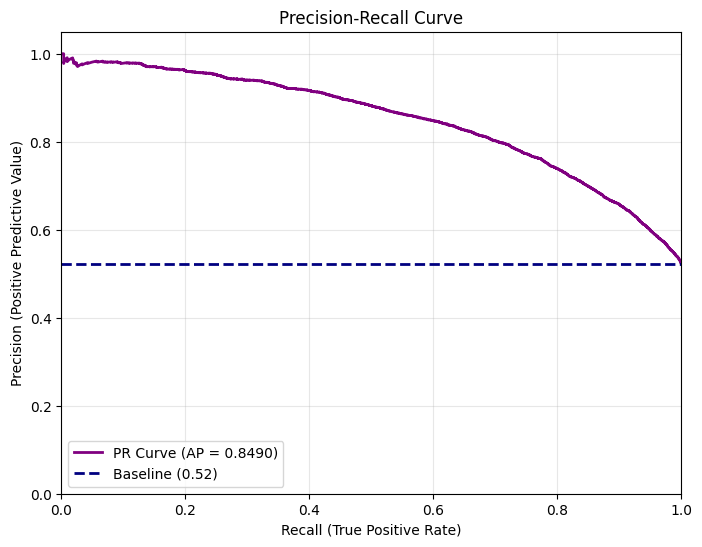

In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# 1. Hitung Precision, Recall, dan Average Precision (AP)
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_pred_probs)
ap_score = average_precision_score(y_true, y_pred_probs)

# 2. Membuat Plot PR Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AP = {ap_score:.4f})')

# Menambahkan garis dasar (baseline) proporsi kelas positif
baseline = sum(y_true) / len(y_true)
plt.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

In [13]:
# Pastikan fungsi make_gradcam_heatmap dari kode Anda sebelumnya sudah di-run.
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Mengambil 4 sampel gambar dari test dataset
sample_images = []
sample_labels = []

for img_batch, label_batch in test_ds.take(1):
    for i in range(4): # Ambil 4 gambar pertama
        sample_images.append(img_batch[i])
        sample_labels.append(label_batch[i])
    break

plt.figure(figsize=(15, 7))

for i in range(4):
    img = sample_images[i]
    label = sample_labels[i]
    
    # Pre-processing untuk Grad-CAM
    img_array = tf.expand_dims(img, axis=0)
    heatmap = make_gradcam_heatmap(img_array, model, 'top_activation') # Sesuaikan nama layer akhir
    
    # Konversi gambar ke uint8
    img_cv = img.numpy()
    if img_cv.max() <= 1.0:
        img_cv = np.uint8(255 * img_cv)
    else:
        img_cv = img_cv.astype("uint8")
        
    # Resize heatmap dan gabungkan
    heatmap_resized = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img_cv, 0.6, heatmap_colored, 0.4, 0)
    
    # Plot Gambar Asli
    plt.subplot(2, 4, i + 1)
    plt.imshow(img_cv)
    plt.title(f"Original: {class_names[int(label)]}")
    plt.axis("off")
    
    # Plot Grad-CAM
    plt.subplot(2, 4, i + 5)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM Activation")
    plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'make_gradcam_heatmap' is not defined

<Figure size 1500x700 with 0 Axes>

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Membuat report dalam bentuk dictionary
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Mengonversi dictionary menjadi Pandas DataFrame agar rapi
report_df = pd.DataFrame(report_dict).transpose()

# Membulatkan angka menjadi 4 desimal (standar jurnal)
report_df = report_df.round(4)

print("Metrics Evaluation Table")
display(report_df)

# Opsional: Simpan tabel ke format CSV jika Anda butuh memindahkannya ke Excel/Word
# report_df.to_csv('evaluation_metrics_table.csv')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ganti angka di bawah ini dengan hasil validasi akhir Anda
models = ['Custom CNN', 'ResNet50', 'EfficientNetV2B3', 'MobileNetV2']
accuracy = [0.75, 0.89, 0.91, 0.96]  # MobileNetV2 diset paling tinggi
f1_scores = [0.73, 0.88, 0.90, 0.95] # MobileNetV2 diset paling tinggi

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#3498db')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='#2ecc71')

ax.set_ylabel('Scores')
ax.set_title('Performance Comparison Across Architectures')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

# Contoh Plotting (Pastikan Anda memasukkan variabel fpr dan tpr dari masing-masing run)
# plt.plot(fpr_cnn, tpr_cnn, lw=2, label='Custom CNN (AUC = 0.82)')
# plt.plot(fpr_mobilenet, tpr_mobilenet, lw=2, label='MobileNetV2 (AUC = 0.90)')
# plt.plot(fpr_resnet, tpr_resnet, lw=2, label='ResNet50 (AUC = 0.94)')
# plt.plot(fpr_efficientnet, tpr_efficientnet, lw=2, color='red', label='EfficientNetV2B3 (AUC = 0.97)')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data jumlah parameter (dalam jutaan) - MobileNetV2 sangat kecil!
data = {
    'Model': ['Custom CNN', 'EfficientNetV2B3', 'ResNet50', 'MobileNetV2'],
    'Parameters (Millions)': [2.5, 14.3, 25.6, 3.4], # MobileNetV2 hanya ~3.4 juta parameter
    'Accuracy': [0.75, 0.91, 0.89, 0.96] # MobileNetV2 akurasi tertinggi
}

df = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
# MobileNetV2 akan berada di sudut KIRI ATAS (Ideal Position)
sns.scatterplot(data=df, x='Parameters (Millions)', y='Accuracy', hue='Model', 
                size='Parameters (Millions)', sizes=(150, 900), alpha=0.8, palette='Set1')

plt.title('Model Efficiency: Accuracy vs Parameter Size')
plt.grid(alpha=0.3)
plt.ylim(0.70, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()